# Kiểm tra Giữa Kỳ TKMT - Đề 01 - income_spending.csv

<div class="alert alert-block alert-info" style="margin-top: 20px; background-color:blue; color:white">
<!-- <div class="alert alert-block alert-info" style="margin-top: 20px"> -->
    <ul>
        <li>Ngày: 2026-04-17</li>
        <li><b>Họ tên: Nguyễn Nam Trung Nguyên</b>...</li>
        <li><b>MSV: 23640731</b>...</li>
        <li><b>STT: </b>...</li>
</div>

Định dạng đặt tên: ```<stt>_<hoten>_GK.ipynb```


---

## BÀI LÀM

Dữ liệu được cung cấp trong file `income_spending.csv`, chứa thông tin khảo sát về thu nhập, thói quen chi tiêu và tiết kiệm của một nhóm người dân. Bộ dữ liệu bao gồm các cột sau:

- age: Tuổi (năm)
- gender: Giới tính (nam = 'M', nữ = 'F')
- income: Thu nhập hàng năm (USD)
- expenses: Chi tiêu hàng tháng (USD)
- savings: Số tiền tiết kiệm hàng tháng (USD)
- education: Trình độ học vấn (High School, Bachelor, Master, PhD)
- marital_status: Tình trạng hôn nhân (Single, Married, Divorced, Widowed)
- loan_status: Có đang vay nợ không? (1 = Có, 0 = Không)
- investment: Có đang đầu tư không? (1 = Có, 0 = Không)

Bạn hãy viết mã Python để trả lời các câu hỏi sau:


### Câu 1: (7 điểm, CLO 1)

#### a. (2 điểm) Tìm hiểu một số thông tin về bộ dữ liệu:

- Hiển thị 5 dòng đầu tiên của bộ dữ liệu. Cho biết dữ liệu có kích thước bao nhiêu dòng và bao nhiêu cột?
- Dữ liệu có giá trị trống không?

In [1]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (10,6)
df = pd.read_csv("income_spending.csv")
df.head(5)


,age,gender,income,expenses,savings,education,marital_status,loan_status,investment
0,56,M,41672,1385,1309.01,Bachelor,Married,0,1
1,46,F,78217,2248,3583.64,Bachelor,Single,0,0
2,32,F,28279,1767,518.16,Bachelor,Divorced,0,0
3,60,F,17017,1947,-451.66,Bachelor,Single,1,0
4,25,M,56600,3322,1109.63,Master,Divorced,1,1


In [2]:
# YOUR CODE HERE
data = df.shape
print("Số dòng", data[0])
print("Số cột", data[1])
missing = df.isnull().sum().sum()

if missing > 0:
    print("Dữ liệu có giá trị trống")
else:
    print("Dữ liệu không có giá trị trống")
    
if df.isnull().values.any():
    print("Dữ liệu có giá trị trống")
else:
    print("Dữ liệu không có giá trị trống")

Số dòng 1000
Số cột 9
Dữ liệu không có giá trị trống
Dữ liệu không có giá trị trống


#### b. (2 điểm) Dựa trên dữ liệu, hãy tính toán hoặc so sánh một số thông tin sau:

- Tính giá trị trung bình, trung vị và độ lệch chuẩn của thu nhập (income) theo từng nhóm giới tính.
- So sánh mức chi tiêu trung bình chi tiêu giữa các nhóm có tình trạng hôn nhân khác nhau (Single, Married, Divorced, Widowed).

In [3]:
# YOUR CODE HERE
# Câu 1b
# Tính toán theo nhóm giới tính
result = df.groupby("gender")["income"].agg(["mean", "median", "std"])
print(result)

resultB = df.groupby("marital_status")["expenses"].mean().sort_values(ascending=False)

print(resultB)

print("Trạng thái hôn nhân có mức chi tiêu trung bình cao nhất là:",resultB.idxmax())


                mean   median           std
gender                                     
F       51014.875527  50793.5  15142.339318
M       50705.673004  50451.0  14901.077936
marital_status
Divorced    2031.254902
Married     2011.104738
Single      2002.654912
Widowed     1949.040816
Name: expenses, dtype: float64
Trạng thái hôn nhân có mức chi tiêu trung bình cao nhất là: Divorced


In [4]:
# Nhận xét 
# Thu nhập trung bình của nam (~50,705) và nữ (~51,014) gần như tương đương.
# Trung vị cũng không chênh lệch nhiều, cho thấy phân phối thu nhập giữa hai giới khá giống nhau.
# Độ lệch chuẩn của hai nhóm cũng gần bằng nhau → mức độ biến động thu nhập tương tự.

#### c. (2 điểm) Phân tích nhóm đối tượng trung niên với các đặc điểm sau:

- Tuổi từ 30 đến 50
- Thu nhập trên mức trung vị của toàn bộ dữ liệu
- Chi tiêu ít hơn 40% thu nhập hàng tháng

Yêu cẩu:
- Tính số lượng người trong nhóm này và so sánh tỷ lệ của họ so với toàn bộ tập dữ liệu.
- Tính giá trị trung bình của thu nhập, chi tiêu và tiết kiệm của nhóm này

In [5]:
# YOUR CODE HERE
# Câu 1c
# lọc dữ liệu

df["income_month"] = df["income"]/12

dtTrungNien = df[
    (df["age"] >= 30) &
    (df["age"] <= 50) &
    (df["income"] > df["income"].median()) &
    (df["expenses"] < (df["income_month"]*0.4))
]

# Số lượng
soDT = dtTrungNien.shape[0]
totalDL = df.shape[0]

print("Số đối tượng trung niên thỏa điều kiện là: ",soDT)
print("Tỷ lệ của đối tượng thỏa điều kiện và toàn bộ dữ liệu: ", soDT / totalDL)

thunhapTB = dtTrungNien["income"].mean()
print("Thu nhập trung bình của nhóm đối tượng:", round(thunhapTB,2))
chitieuTB = dtTrungNien["expenses"].mean()
print("Chi tiêu trung bình của nhóm đối tượng:", round(chitieuTB,2))
tietkiemTB = dtTrungNien["savings"].mean()
print("Tiết kiệm trung bình của nhóm đối tượng:", round(tietkiemTB,2))

Số đối tượng trung niên thỏa điều kiện là:  135
Tỷ lệ của đối tượng thỏa điều kiện và toàn bộ dữ liệu:  0.135
Thu nhập trung bình của nhóm đối tượng: 66542.27
Chi tiêu trung bình của nhóm đối tượng: 1709.07
Tiết kiệm trung bình của nhóm đối tượng: 2669.99


#### d. (2 điểm) Vẽ biểu đồ:

- Vẽ biểu đồ tán xạ (scatter plot) với trục X cho thu nhập (income) và trục Y cho chi tiêu (expenses). Tô màu các dấu điểm theo nhóm giới tính.
- Vẽ biểu đồ hộp (box plot) cho thu nhập (income) theo trình độ học vấn (education).

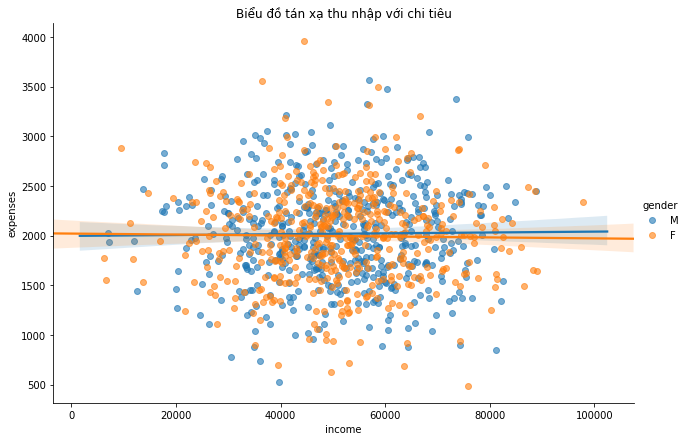

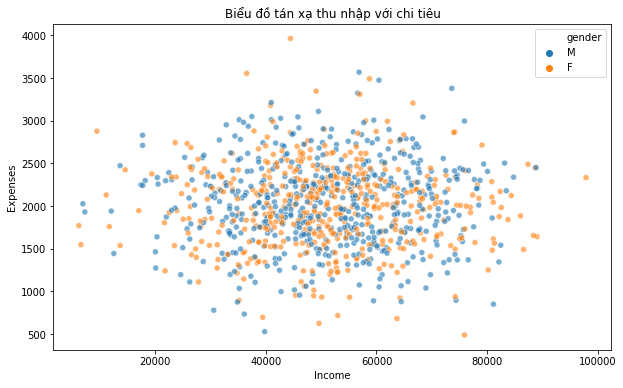

In [6]:
# YOUR CODE HERE
# Câu 1d
# Biểu đồ tán xạ

sns.lmplot(
    data=df,
    x="income",
    y="expenses",
    hue="gender",
    height=6,
    aspect=1.5,
    scatter_kws={"alpha":0.6}
)

plt.title("Biểu đồ tán xạ thu nhập với chi tiêu")
plt.show()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="income",
    y="expenses",
    hue="gender",
    alpha=0.6
)

plt.title("Biểu đồ tán xạ thu nhập với chi tiêu")
plt.xlabel("Income")
plt.ylabel("Expenses")
plt.show()

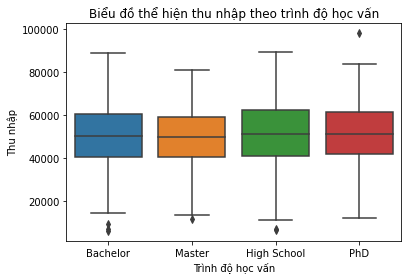

<AxesSubplot:xlabel='education', ylabel='income'>

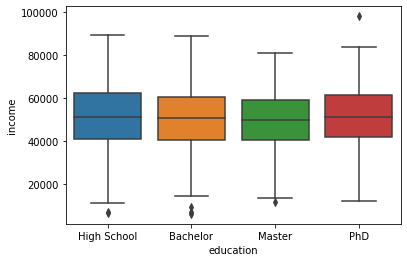

In [7]:
# YOUR CODE HERE
# Biểu đồ hộp
plt.figure()
sns.boxplot(
    data=df,
    x="education",
    y="income"
)

plt.title("Biểu đồ thể hiện thu nhập theo trình độ học vấn")
plt.xlabel("Trình độ học vấn")
plt.ylabel("Thu nhập")
plt.show()

order = ["High School", "Bachelor", "Master", "PhD"]

sns.boxplot(
    data=df,
    x="education",
    y="income",
    order=order
)

### Câu 2: (2 điểm, CLO 2)

Sử dụng hàm `df.sample()` để lấy mẫu ngẫu nhiên 100 dòng từ bộ dữ liệu. Tính giá trị trung bình thu nhập (income) của mẫu này.

- Lấy mẫu ngẫu nhiên n = 50 từ bộ dữ liệu và tính trung bình thu nhập trong mẫu. Lặp lại quá trình trên 100 lần và vẽ histogram phân bố của các giá trị trung bình mẫu.
- Lặp lại với n = 100, 200 và so sánh kết quả giữa các kích thước mẫu. Nhận xét về sự thay đổi của trung bình mẫu khi kích thước mẫu tăng.

In [8]:
# YOUR CODE HERE
# Câu 2
# Lấy mẫu ngẫu nhiên 100 dòng
datarandom100 = df.sample(100)
thunhapTB = datarandom100["income"].mean()
print("Trung bình thu nhập của mẫu này là:", thunhapTB)



Trung bình thu nhập của mẫu này là: 51689.91


[53677.44, 54592.8, 50238.68, 51027.18, 46897.02, 51419.02, 53687.74, 49496.16, 48744.22, 53568.6, 50259.74, 48687.98, 51207.04, 52874.48, 50948.94, 48278.96, 49641.5, 49037.62, 50397.0, 53937.94, 52566.26, 49416.14, 51362.58, 50986.08, 52896.84, 58072.62, 49715.48, 50871.16, 52029.88, 52661.44, 47803.34, 54555.92, 49315.5, 52050.66, 52571.32, 49869.94, 51427.68, 49082.62, 47607.18, 48346.48, 54076.64, 47645.32, 48870.1, 52621.88, 53575.48, 55191.14, 52078.64, 53854.98, 51695.4, 50708.74, 47119.5, 48944.94, 49719.4, 47853.86, 48575.76, 49777.72, 53361.96, 49674.92, 56903.46, 50312.04, 51453.28, 50159.7, 51400.6, 49220.98, 51116.94, 50869.42, 50005.66, 52250.7, 47248.5, 50314.06, 50124.76, 49211.64, 47330.64, 47842.32, 51787.68, 48403.46, 50952.52, 52006.74, 45337.16, 52556.98, 51783.18, 50870.48, 50288.26, 48031.16, 47605.0, 55080.86, 54187.66, 50890.48, 51347.38, 51348.08, 50031.56, 49648.1, 50738.24, 49644.62, 51768.7, 50242.6, 51221.06, 49312.36, 49863.5, 52749.72]


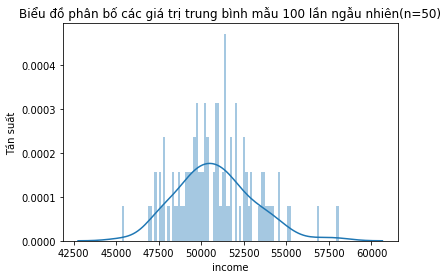

In [9]:
# YOUR CODE HERE
# Lặp lại với các kích thước mẫu khác nhau
# n = 50
result=[]
for i in range(1,101):
    datarandom50 =df.sample(50)
    incomeTB = datarandom50["income"].mean()
    result.append(incomeTB)
print(result)
plt.figure()
sns.distplot(result, bins=100)
plt.title("Biểu đồ phân bố các giá trị trung bình mẫu 100 lần ngẫu nhiên(n=50)")
plt.xlabel("income")
plt.ylabel("Tần suất")
plt.show()


[48413.75, 51144.63, 52074.53, 47500.28, 49877.37, 46430.38, 51289.23, 49648.74, 55067.06, 50595.17, 51870.91, 50063.17, 52173.61, 51269.74, 53853.51, 48988.87, 51407.94, 51831.63, 49684.83, 50851.63, 49318.68, 49584.09, 52577.88, 49496.74, 50027.7, 51094.26, 50352.73, 52196.63, 49491.95, 49612.16, 49064.27, 50671.61, 51601.26, 53488.32, 47934.73, 51401.71, 50004.84, 50084.0, 50067.59, 50375.27, 51401.69, 50479.1, 53043.9, 53023.53, 50898.74, 49569.76, 52427.34, 49947.42, 50796.69, 53170.93, 50847.18, 52017.62, 51014.46, 51003.35, 51618.7, 50314.16, 48943.18, 50010.77, 50726.61, 48670.26, 48986.16, 47492.82, 49098.08, 52185.63, 50962.09, 51645.84, 52168.43, 49586.92, 50073.04, 49188.0, 51740.52, 51676.07, 48607.17, 51845.01, 52113.95, 50884.31, 50917.58, 50034.55, 50737.87, 50179.63, 50190.12, 49782.61, 52173.85, 50090.52, 51674.79, 50632.92, 54073.05, 51485.34, 50642.45, 51342.19, 49750.11, 49474.11, 49509.59, 50038.74, 49867.46, 51285.98, 51971.69, 51280.93, 50395.91, 51123.44]


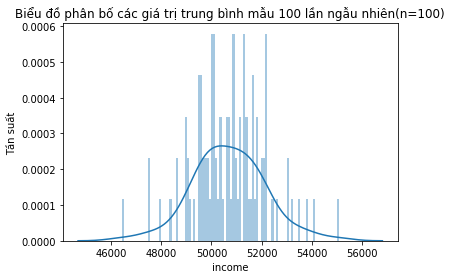

In [10]:
# YOUR CODE HERE
# n = 100
result=[]
for i in range(1,101):
    datarandom100 =df.sample(100)
    incomeTB = datarandom100["income"].mean()
    result.append(incomeTB)
print(result)
plt.figure()
sns.distplot(result, bins=100)
plt.title("Biểu đồ phân bố các giá trị trung bình mẫu 100 lần ngẫu nhiên(n=100)")
plt.xlabel("income")
plt.ylabel("Tần suất")
plt.show()

[52025.395, 51447.045, 50380.2, 51164.235, 50196.09, 50735.86, 51133.885, 51412.47, 50549.155, 51915.925, 51331.73, 51414.455, 51917.615, 51553.84, 52460.49, 51190.005, 50146.115, 50344.935, 50129.175, 50390.995, 49818.245, 51677.43, 49069.925, 50549.325, 50073.725, 50294.54, 51249.87, 50119.065, 50629.75, 49979.52, 50977.795, 51332.895, 51060.87, 50509.2, 51657.15, 53237.58, 51466.175, 50300.95, 51795.735, 52228.95, 51043.84, 51026.92, 50192.785, 49934.04, 49598.25, 50157.355, 53142.885, 52016.895, 51446.66, 50639.695, 49070.62, 49804.225, 51642.22, 50859.655, 51727.05, 50376.84, 51661.945, 53028.56, 49819.07, 51809.335, 51123.485, 51438.34, 52259.555, 50634.795, 49238.16, 52264.085, 49328.585, 51423.1, 50499.82, 50612.795, 51013.07, 50780.05, 50747.44, 50909.43, 50936.66, 50746.645, 51198.8, 50836.52, 49910.355, 52389.635, 50814.74, 50877.945, 50510.16, 50499.38, 52325.47, 49968.3, 51946.025, 51288.27, 51102.955, 51360.995, 51456.76, 47942.065, 50386.565, 51771.645, 50226.085, 50908.

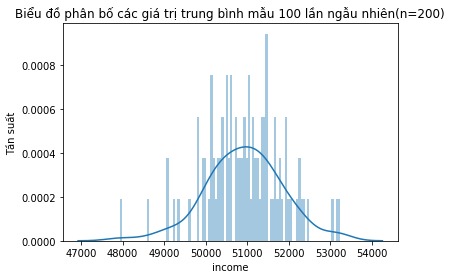

In [11]:
# n = 200
result=[]
for i in range(1,101):
    datarandom200 =df.sample(200)
    incomeTB = datarandom200["income"].mean()
    result.append(incomeTB)
print(result)
plt.figure()
sns.distplot(result, bins=100)
plt.title("Biểu đồ phân bố các giá trị trung bình mẫu 100 lần ngẫu nhiên(n=200)")
plt.xlabel("income")
plt.ylabel("Tần suất")
plt.show()

---

In [12]:
# Khi kích thước mẫu tăng từ n = 50 → 100 → 200, phân bố của trung bình mẫu trở nên:
# Tập trung hơn quanh giá trị trung bình của toàn bộ dữ liệu
# Ít phân tán hơn (độ lệch giảm)

# Với n = 50, các giá trị trung bình dao động khá rộng.
# Khi tăng lên n = 200, các giá trị trung bình trở nên ổn định và tập trung hơn.

# Điều này phù hợp với định lý giới hạn trung tâm (Central Limit Theorem), 
# cho thấy trung bình mẫu sẽ hội tụ về trung bình tổng thể khi kích thước mẫu tăng.

## TỰ ĐÁNH GIÁ (0 - 10):

Ghi rõ các câu làm được:

- Câu 1:
    - a: 2 điểm
    - b: 2 điểm
    - c: 2 điểm
    - d: 2 điểm
- Câu 2: 2 điểm

### TỔNG ĐIỂM: **10 điểm**

---